In [1]:
import os
import re
import seaborn as sns
import matplotlib.pyplot as plt
import random
from sklearn.model_selection import train_test_split
import warnings
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img

warnings.filterwarnings("ignore", category=FutureWarning)

# Define dataset path
dataset_path = "/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset"

In [2]:
# Function to count the number of images in each folder
def count_images_in_folders(base_path, folder_list):
    counts = {}
    for folder in folder_list:
        folder_path = os.path.join(base_path, folder)
        if os.path.exists(folder_path):
            counts[folder] = len(os.listdir(folder_path))  # Fixed file listing
        else:
            counts[folder] = 0
    return counts

folders = ["train/benign", "train/malignant", "test/benign", "test/malignant"]
image_counts = count_images_in_folders(dataset_path, folders)

# Print the count of images
for folder, count in image_counts.items():
    print(f"{folder}: {count} images")

train/benign: 5000 images
train/malignant: 4605 images
test/benign: 500 images
test/malignant: 500 images


In [3]:
# Define paths for train and test sets
train_benign_path = os.path.join(dataset_path, "train", "benign")
train_malignant_path = os.path.join(dataset_path, "train", "malignant")
test_benign_path = os.path.join(dataset_path, "test", "benign")
test_malignant_path = os.path.join(dataset_path, "test", "malignant")


In [4]:
# Function to check filename consistency
def check_filename_consistency(base_path, subfolders):
    for subfolder in subfolders:
        folder_path = os.path.join(base_path, subfolder)
        if os.path.exists(folder_path):
            for filename in os.listdir(folder_path):  # Fixed file listing
                if not re.match(r"melanoma_\d+\.jpg", filename):
                    print(f"Issue in {subfolder}: {filename}")

check_filename_consistency(dataset_path, folders)

In [5]:
# Creating a validation split
validation_base_path = "/kaggle/working/validation"
subfolders = ["train/benign", "train/malignant"]
os.makedirs(validation_base_path, exist_ok=True)

def create_validation_split(base_path, subfolders, validation_base_path, split_ratio=0.2):
    for subfolder in subfolders:
        source_folder = os.path.join(base_path, subfolder)
        if not os.path.exists(source_folder):
            print(f"Source folder {source_folder} does not exist. Skipping...")
            continue
        
        target_folder = os.path.join(validation_base_path, subfolder.split("/")[-1])
        os.makedirs(target_folder, exist_ok=True)

        images = os.listdir(source_folder)  # Fixed file listing
        labels = [subfolder] * len(images)
        _, val_images = train_test_split(images, test_size=split_ratio, random_state=42)  # Fixed train-test split
        
        for val_image in val_images:
            src = os.path.join(source_folder, val_image)
            dst = os.path.join(target_folder, val_image)
            if not os.path.exists(dst):
                os.symlink(src, dst)

create_validation_split(dataset_path, subfolders, validation_base_path)
print("Validation split created successfully!")

Validation split created successfully!


In [6]:
# Count images in train/test directories
train_benign = len(os.listdir(train_benign_path))
train_malignant = len(os.listdir(train_malignant_path))
test_benign = len(os.listdir(test_benign_path))
test_malignant = len(os.listdir(test_malignant_path))

# Print counts
print(f"train_benign: {train_benign} images")
print(f"train_malignant: {train_malignant} images")
print(f"test_benign: {test_benign} images")
print(f"test_malignant: {test_malignant} images")

train_benign: 5000 images
train_malignant: 4605 images
test_benign: 500 images
test_malignant: 500 images


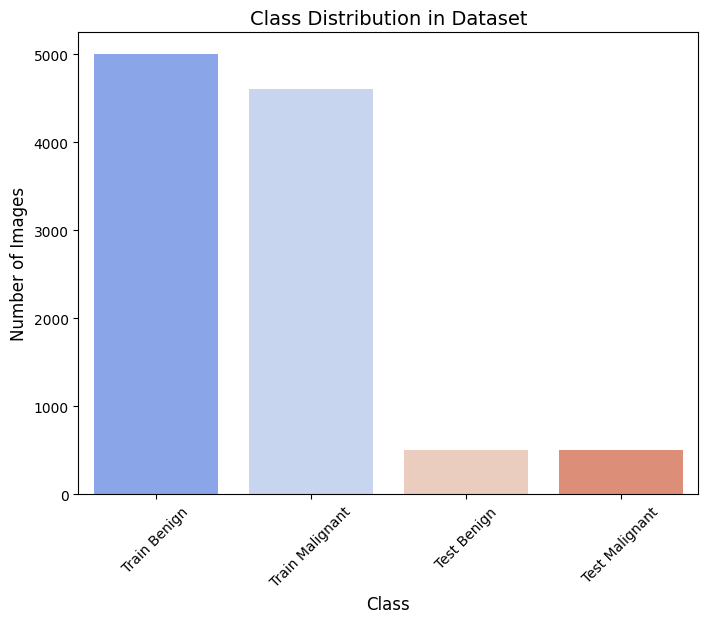

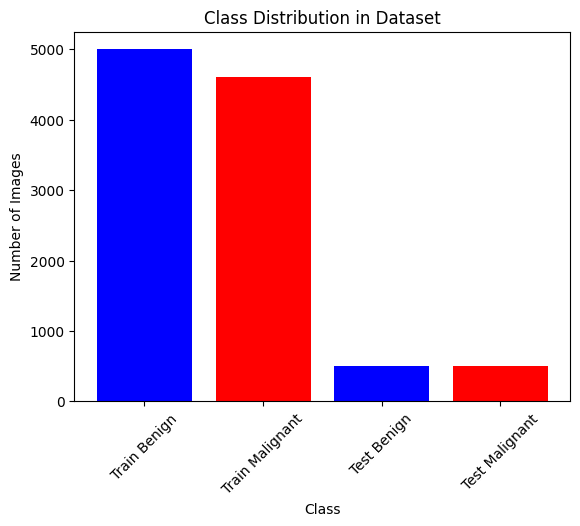

Train Benign to Malignant Ratio: 1.09
Test Benign to Malignant Ratio: 1.00


In [7]:
# Dictionary for visualization
class_counts = {
    "Train Benign": train_benign,
    "Train Malignant": train_malignant,
    "Test Benign": test_benign,
    "Test Malignant": test_malignant
}

# Bar Plot using Seaborn
plt.figure(figsize=(8, 6))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette='coolwarm')
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Class Distribution in Dataset', fontsize=14)
plt.xticks(rotation=45)
plt.show()

# Bar Plot using Matplotlib
plt.bar(class_counts.keys(), class_counts.values(), color=['blue', 'red', 'blue', 'red'])
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Class Distribution in Dataset')
plt.xticks(rotation=45) 
plt.show()

# Train-test ratio
train_ratio = train_benign / train_malignant
test_ratio = test_benign / test_malignant

print(f"Train Benign to Malignant Ratio: {train_ratio:.2f}")
print(f"Test Benign to Malignant Ratio: {test_ratio:.2f}")

In [8]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2 ) 


In [9]:
def plot_sample_images(class_dir, class_label, num_images=9):
    """Displays a grid of sample images from a given class directory."""
    image_files = os.listdir(class_dir)
    random.shuffle(image_files)
    
    fig, axes = plt.subplots(3, 3, figsize=(8, 8))
    fig.suptitle(f"Sample Images - {class_label}", fontsize=14)
    
    for i, ax in enumerate(axes.flat):
        if i >= len(image_files):
            break
        
        img_path = os.path.join(class_dir, image_files[i])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  
        
        ax.imshow(img)
        ax.axis("off")
    
    plt.show()

Found 9605 images belonging to 2 classes.


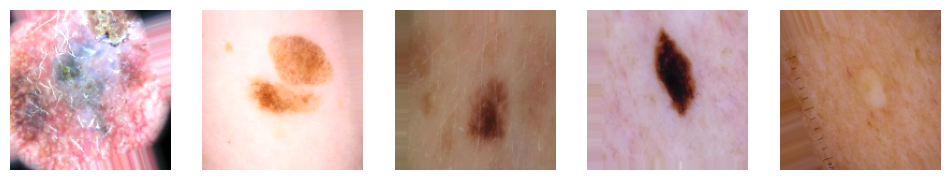

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import matplotlib.pyplot as plt

dataset_path = "/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images"

if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"❌ Dataset folder not found at {dataset_path}. Please check the path!")

train_dir = "/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/train"

if not os.path.exists(train_dir):
    raise FileNotFoundError(f"❌ 'train' directory not found in {dataset_path}. Check dataset structure!")

data_generator = ImageDataGenerator(
    rescale=1./255,              
    rotation_range=20,           
    width_shift_range=0.1,       
    height_shift_range=0.1,       
    brightness_range=[0.8, 1.2]   
)
train_generator = data_generator.flow_from_directory(
    train_dir,                    
    target_size=(150, 150),      
    batch_size=32,               
    class_mode='binary',          
    shuffle=True                  
)

def show_augmented_images(generator, num_images=5):
    images, labels = next(generator) 
    
    plt.figure(figsize=(12, 6))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(images[i])  # Show the image
        plt.axis("off")  # Hide axes
    plt.show()

show_augmented_images(train_generator)



In [11]:
#Normalize pixel values
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def normalize_dataset(dataset_path, target_size=(224, 224)):
   
    normalized_images = {}

    for root, _, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):  
                image_path = os.path.join(root, file)
                image = load_img(image_path, target_size=target_size)  
                image_array = img_to_array(image) / 255.0  
                normalized_images[file] = image_array  
    return normalized_images

dataset_path = "path/to/your/dataset"  
normalized_data = normalize_dataset(dataset_path)

print(f"Total images normalized: {len(normalized_data)}")


Total images normalized: 0


In [12]:
#Implemented a Convolutional Neural Network (CNN)
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50, EfficientNetB0

# Define CNN Model
cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),
    
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),
    
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),
    
    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    
    Dense(1, activation='sigmoid')  # Binary classification (melanoma vs non-melanoma)
])

# Compile CNN Model
cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Implement ResNet50
resnet_model = ResNet50(weights=None, input_shape=(224, 224, 3), classes=1)
resnet_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Implement EfficientNetB0
efficientnet_model = EfficientNetB0(weights=None, input_shape=(224, 224, 3), classes=1)
efficientnet_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Model Summaries
print("CNN Model Summary:")
cnn_model.summary()
print("\nResNet50 Model Summary:")
resnet_model.summary()
print("\nEfficientNetB0 Model Summary:")
efficientnet_model.summary()


/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,497 (42.61 MB)

...

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ normalization[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 4,008,829 (15.29 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [13]:
# Compile the Model with different optimizers

# Using Adam Optimizer
cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Using RMSprop Optimizer
resnet_model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

# Using Adagrad (Adaptive) Optimizer
efficientnet_model.compile(optimizer='adagrad', loss='binary_crossentropy', metrics=['accuracy'])

# Print statements to confirm successful compilation with different optimizers
print("Models have been successfully compiled with different optimization techniques.")
print("CNN Model: Adam Optimizer")
print("ResNet50 Model: RMSprop Optimizer")
print("EfficientNetB0 Model: Adagrad Optimizer")
print("Optimization setup complete. Models are ready for training.")


Models have been successfully compiled with different optimization techniques.
CNN Model: Adam Optimizer
ResNet50 Model: RMSprop Optimizer
EfficientNetB0 Model: Adagrad Optimizer
Optimization setup complete. Models are ready for training.


In [14]:
#train the Model and Validate Performance
import os
import shutil
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

dataset_path = "/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset"

train_benign_path = os.path.join(dataset_path, "train", "benign")
train_malignant_path = os.path.join(dataset_path, "train", "malignant")
test_benign_path = os.path.join(dataset_path, "test", "benign")
test_malignant_path = os.path.join(dataset_path, "test", "malignant")

if not os.path.exists(train_benign_path) or not os.path.exists(train_malignant_path):
    raise FileNotFoundError("Error: 'train' folder does not exist. Check dataset path!")

if not os.path.exists(test_benign_path) or not os.path.exists(test_malignant_path):
    raise FileNotFoundError("Error: 'test' folder does not exist. Check dataset path!")

val_dir = "/kaggle/working/validation"
val_benign_path = os.path.join(val_dir, "benign")
val_malignant_path = os.path.join(val_dir, "malignant")

os.makedirs(val_benign_path, exist_ok=True)
os.makedirs(val_malignant_path, exist_ok=True)

def create_validation_split(train_path, val_path, split_ratio=0.2):
    images = os.listdir(train_path)
    train_images, val_images = train_test_split(images, test_size=split_ratio, random_state=42)

    for img in val_images:
        src = os.path.join(train_path, img)
        dst = os.path.join(val_path, img)

        if not os.path.exists(dst):
            shutil.copy(src, dst)  

create_validation_split(train_benign_path, val_benign_path)
create_validation_split(train_malignant_path, val_malignant_path)

print(" Validation set created successfully in '/kaggle/working/'!")

train_datagen = ImageDataGenerator(rescale=1.0/255)
val_datagen = ImageDataGenerator(rescale=1.0/255)

train_data = train_datagen.flow_from_directory(
    os.path.join(dataset_path, "train"),
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

val_data = val_datagen.flow_from_directory(
    val_dir,  #  Use the new validation directory in /kaggle/working/
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

cnn_model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

epochs = 2
history_cnn = cnn_model.fit(train_data, validation_data=val_data, epochs=epochs)

print(" Model Training Complete!")

model_save_path = "/kaggle/working/best_model.h5" 
cnn_model.save(model_save_path)
print(f"Model saved at: {model_save_path}")

print(" Checking saved model files:", os.listdir("/kaggle/working/"))

cnn_model = tf.keras.models.load_model(model_save_path)
print(" Model Loaded Successfully!")


 Validation set created successfully in '/kaggle/working/'!
Found 9605 images belonging to 2 classes.
Found 1921 images belonging to 2 classes.
Epoch 1/2


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1738992688.631560     111 service.cc:145] XLA service 0x7967a8009cb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1738992688.631621     111 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


  3/301 ━━━━━━━━━━━━━━━━━━━━ 24s 83ms/step - accuracy: 0.4983 - loss: 4.7041

I0000 00:00:1738992692.399360     111 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


301/301 ━━━━━━━━━━━━━━━━━━━━ 56s 165ms/step - accuracy: 0.7456 - loss: 0.9388 - val_accuracy: 0.8876 - val_loss: 0.2781
Epoch 2/2
301/301 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - accuracy: 0.8736 - loss: 0.2960 - val_accuracy: 0.8886 - val_loss: 0.2481
 Model Training Complete!
Model saved at: /kaggle/working/best_model.h5
 Checking saved model files: ['.virtual_documents', 'best_model.h5', 'validation']
 Model Loaded Successfully!


61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step
 Accuracy: 0.5128
 Precision: 0.4909
 Recall: 0.4387
 F1-score: 0.4633

 Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.58      0.55      1000
           1       0.49      0.44      0.46       921

    accuracy                           0.51      1921
   macro avg       0.51      0.51      0.51      1921
weighted avg       0.51      0.51      0.51      1921



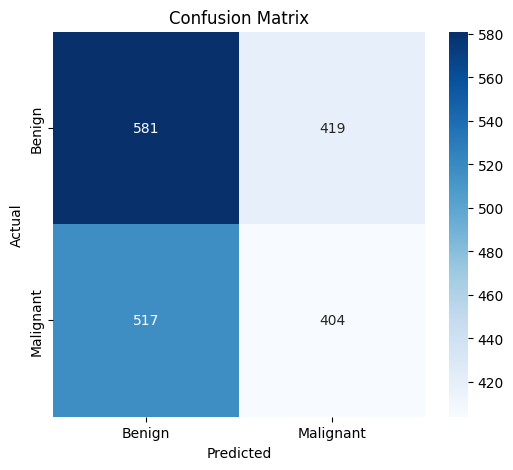

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_true = val_data.classes 
y_pred_probs = cnn_model.predict(val_data)  # Predicted probabilities
y_pred = (y_pred_probs > 0.5).astype(int)  # Convert probabilities to binary (0 or 1)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f" Accuracy: {accuracy:.4f}")
print(f" Precision: {precision:.4f}")
print(f" Recall: {recall:.4f}")
print(f" F1-score: {f1:.4f}")
print("\n Classification Report:\n", classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Benign", "Malignant"], yticklabels=["Benign", "Malignant"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
